In [2]:
## load libraries
import spacy
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
!python -m spacy download ru_core_news_sm

     ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
     --------------- ------------------------ 6.0/15.3 MB 28.4 MB/s eta 0:00:01
     ---------------------------- ---------- 11.3/15.3 MB 27.1 MB/s eta 0:00:01
     --------------------------------------  15.2/15.3 MB 24.5 MB/s eta 0:00:01
     --------------------------------------- 15.3/15.3 MB 23.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')


In [3]:
## load the data
df = pd.read_csv("mid_ru_trimmed_from_20130101.csv")


In [4]:
nlp = spacy.load("ru_core_news_sm")
# NLP pipeline for Russian language (version "ld" is 500mb, so i went for a simpler version "md")
# check lemmatization accuracy
# https://spacy.io/models/ru#ru_core_news_lg


In [5]:
## get the length of the dataframe
len(df)

28706

In [29]:
## get the columns
df.columns
#sample text
df.sample(2)

,doc_id,text,date,datetime,title,internal_id,url_id,translations,countries,url
16815,mid.ru_ru_1461742,"Уважаемый Сооронбай Шарипович,\n\nКоллеги,\n\n...",2019-05-22 14:59:00+00:00,2019-05-22T14:59:00Z,Вступительное слово Министра иностранных дел Р...,1060-22-05-2019,1461742,ru; en,NaN,https://mid.ru/ru/foreign_policy/news/1461742/
26216,mid.ru_ru_1851459,СООБЩЕНИЕ ДЛЯ СМИ\n\n \n\n31 января заместител...,2023-01-31 12:55:00+00:00,2023-01-31T12:55:00Z,О встрече заместителя Министра иностранных дел...,149-31-01-2023,1851459,NaN,NaN,https://mid.ru/ru/foreign_policy/news/1851459/


In [7]:
## create the datetime object
df['date'] = pd.to_datetime(df['datetime'], errors='coerce')

# Check for rows where conversion failed
if df['date'].isna().any():
    print("Error converting some datetime values")

In [8]:
## prepare timeseries
countsmonths = df.set_index('date').resample("1M").count()
countsyears = df.set_index('date').resample("1YE").count()

C:\Users\hits9\AppData\Local\Temp\ipykernel_19444\1241215534.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  countsmonths = df.set_index('date').resample("1M").count()


In [9]:
countsyears

,doc_id,text,datetime,title,internal_id,url_id,translations,countries,url
date,,,,,,,,,
2013-12-31 00:00:00+00:00,2704,2703,2704,2704,2628,2704,641,0,2704
2014-12-31 00:00:00+00:00,3021,3018,3021,3021,2968,3021,1470,1,3021
2015-12-31 00:00:00+00:00,2585,2583,2585,2585,2545,2585,1409,149,2585
2016-12-31 00:00:00+00:00,2444,2444,2444,2444,2428,2444,1836,1395,2444
2017-12-31 00:00:00+00:00,2532,2532,2532,2532,2529,2532,2249,1410,2532
2018-12-31 00:00:00+00:00,2491,2489,2491,2491,2488,2491,1889,375,2491
2019-12-31 00:00:00+00:00,2669,2669,2669,2669,2666,2669,1385,1645,2669
2020-12-31 00:00:00+00:00,2301,2301,2301,2301,2298,2301,1223,1913,2301
2021-12-31 00:00:00+00:00,2683,2681,2683,2683,2679,2683,723,1848,2683


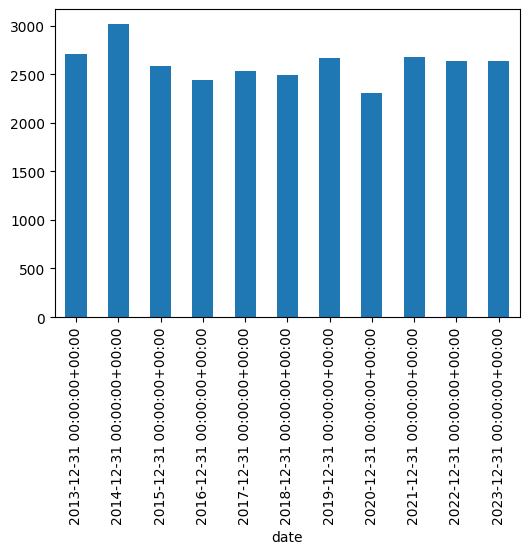

In [10]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1,1,1)
countsyears['text'].plot(kind='bar',ax=ax)
plt.show()

In [11]:
## define the nlp object
nlp = spacy.load("ru_core_news_sm")

In [12]:
## choose some sample text, for instance the 5000th paragraph
text = df['text'][500]
text

'СООБЩЕНИЕ ДЛЯ СМИ\n\nВ ходе состоявшегося 12 марта телефонного разговора статс-секретаря - заместителя Министра иностранных дел Российской Федерации Г.Б.Карасина с первым заместителем Министра иностранных дел Украины Р.М.Демченко были обсуждены некоторые актуальные вопросы российско - украинских отношений, включая тематику взаимодействия двух стран в международных делах.\n\n12 марта 2013 года'

In [13]:
## run the pipeline
nlp_doc = nlp(text)

In [15]:
for token in nlp_doc[:10]:
    print (token,'->',token.lemma_)


СООБЩЕНИЕ -> сообщение
ДЛЯ -> для
СМИ -> сми


 -> 


В -> в
ходе -> ход
состоявшегося -> состояться
12 -> 12
марта -> март
телефонного -> телефонный


In [35]:
## count nouns and GPEs
N_nouns = 0
N_verbs = 0
GPEs = []
Nouns = []
Verbs = []
for token in nlp_doc:
    if token.pos_ == "NOUN":
        Nouns.append(token.text)
    elif token.pos_ == "VERB":
        Verbs.append(token.text)
print(Nouns)
print(Verbs)

['СООБЩЕНИЕ', 'СМИ', 'ходе', 'марта', 'разговора', 'статс', '-', 'секретаря', '-', 'заместителя', 'дел', 'Г.Б.Карасина', 'заместителем', 'дел', 'вопросы', 'отношений', 'тематику', 'взаимодействия', 'стран', 'делах', 'марта', 'года']
['состоявшегося', 'обсуждены']


In [36]:
#list entities:
for ent in nlp_doc.ents:
    print(ent.text, ent.label_)

СМИ ORG
Российской Федерации LOC
Г.Б.Карасина ORG
Украины LOC
Р.М.Демченко PER


In [17]:
## define the documents
documents = list(df['text'])

In [ ]:

documents_nlp = []
for d in tqdm(nlp.pipe(documents, n_process=2, batch_size=30), total=len(documents)):
    documents_nlp.append(d)


100%|██████████| 28706/28706 [42:09<00:00, 11.35it/s]


In [23]:
import random
from collections import Counter

# Count all lemmatized nouns in the corpus
noun_counts = Counter(
    token.lemma_.lower() for doc in documents_nlp for token in doc if token.pos_ == "NOUN"
)

# Filter lemmatized nouns with at least 4 characters and occurring at least 1000 times
filtered_nouns = [noun for noun, count in noun_counts.items() if len(noun) >= 4 and count >= 1000]

# Randomly select 5 lemmatized nouns from the filtered list
random_nouns = random.sample(filtered_nouns, 5)

print(random_nouns)

['эффективность', 'частность', 'запрещение', 'размещение', 'проявление']


In [ ]:
def return_nouns(nlpdoc):
    ## define a nounlist
    nounlist = []
    for token in nlpdoc:
        if token.pos_ == 'NOUN':
        ## check if token is noun
            ## append token.text to
            nounlist.append(token.lemma_)
    return nounlist

Nouns_list = []
Nouns_list_list = []
for nlpdoc in documents_nlp:
    Nouns = return_nouns(nlpdoc)
    Nouns_list.extend(Nouns)
    Nouns_list_list.append(Nouns)
#Nouns_list

In [25]:
len(Nouns_list_list)

28706

In [ ]:
# count of most common nouns
from collections import Counter
Counter(Nouns_list).most_common(20)

[('страна', 75306),
 ('вопрос', 73326),
 ('дело', 55093),
 ('год', 49265),
 ('отношение', 38436),
 ('сторона', 38144),
 ('государство', 36623),
 ('-', 34110),
 ('ситуация', 33156),
 ('сотрудничество', 29606),
 ('г.', 28235),
 ('безопасность', 26207),
 ('решение', 24387),
 ('сми', 24313),
 ('право', 24018),
 ('развитие', 23873),
 ('работа', 23015),
 ('представитель', 22097),
 ('человек', 21693),
 ('министр', 21211)]

In [27]:
# Save the target words to a CSV file
import pandas as pd

# --- PARAMETERS: your list of lemmas (all lowercase) ---
target_lemmas = [nlp(word)[0].lemma_.lower() for word in ['денацификация','демилитаризация', 'бандеровцы', 'англосаксы', 'биолаборатории',\
                                                           'русофобия', 'прокси', 'соотечественников', 'геноцид', 'нацбаты', 'укронацисты',\
                                                              'марионетка', 'референдум', 'освободители', 'бандеризация', 'дезинформация',\
                                                                  'воссоединение', 'империалистический','деколонизация', 'спецоперация', 'СВО', 'война',\
                                                                    'терроризм', 'вторжение', 'нападение', 'защита',\
                                                                          'эффективность', 'частность', 'запрещение', 'размещение', 'проявление']]

#target_lemma = nlp("марионетка")[0].lemma_.lower() consider lemmatizing the target words "соотечественников" 

# We'll build one record per row/document
records = []

for row_index, (nlpdoc, date) in enumerate(zip(documents_nlp, df['date'])):
    # 1) total "words" = count of non-punct, non-space tokens
    total_words = sum(1 for tok in nlpdoc if not (tok.is_punct or tok.is_space))
    
    # 2) count each target lemma in this doc
    counts = {
        f'Count of {lemma}': sum(1 for tok in nlpdoc if tok.lemma_.lower() == lemma)
        for lemma in target_lemmas
    }
    
    # 3) assemble the record
    rec = {
        'Date': pd.to_datetime(date).date(),
        'Total words': total_words,
        **counts
    }
    records.append(rec)

# 4) turn into DataFrame and sum up by Date
daily = (
    pd.DataFrame(records)
      .groupby('Date', as_index=False)
      .sum()
)

# 5) export
daily.to_csv('daily_lemma_counts.csv', index=False)

print(daily.head())


         Date  Total words  Count of денацификация  Count of демилитаризация  \
0  2013-01-01          115                       0                         0   
1  2013-01-05          244                       0                         0   
2  2013-01-08          245                       0                         0   
3  2013-01-09          910                       0                         0   
4  2013-01-10         1831                       0                         0   

   Count of бандеровец  Count of англосакс  Count of биолаборатории  \
0                    0                   0                        0   
1                    0                   0                        0   
2                    0                   0                        0   
3                    0                   0                        0   
4                    0                   0                        0   

   Count of русофобия  Count of прокси  Count of соотечественник  ...  \
0                  